# Рубежная работа - Касьяненко Вера (P3420, 368283)

# Импорт библиотек

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 31.5 MB/s eta 0:00:00


In [ ]:
import os, re
import numpy as np
import pandas as pd
import mne
from scipy.signal import welch
from scipy.stats import median_abs_deviation, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

# Загрузка и подготовка данных

In [ ]:
!wget -r -N -c -np https://physionet.org/files/eegmat/1.0.0/

--2025-10-30 10:00:08--  https://physionet.org/files/eegmat/1.0.0/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘physionet.org/files/eegmat/1.0.0/index.html’

physionet.org/files     [ <=>                ]   9.11K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2025-10-30 10:00:08 (260 MB/s) - ‘physionet.org/files/eegmat/1.0.0/index.html’ saved [9326]

Loading robots.txt; please ignore errors.
--2025-10-30 10:00:08--  https://physionet.org/robots.txt
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 22 [text/plain]
Saving to: ‘physionet.org/robots.txt’

physionet.org/robot 100%[===================>]      22  --.-KB/s    in 0s      

2025-10-30 10:00:08 (16.9 MB/s) - ‘physionet.org/robots.txt’ saved [22/22]

--2025-10-30 10:00:

In [ ]:
# Папка, где лежат EDF-файлы
BASE = "/content/physionet.org/files/eegmat/1.0.0"

# Метаданные
info = pd.read_csv(os.path.join(BASE, "subject-info.csv"))
info['Subject'] = info['Subject'].str.strip()

info.head()

,Subject,Age,Gender,Recording year,Number of subtractions,Count quality
0,Subject00,21,F,2011,9.70,0
1,Subject01,18,F,2011,29.35,1
2,Subject02,19,F,2012,12.88,1
3,Subject03,17,F,2010,31.00,1
4,Subject04,17,F,2010,8.60,0


In [ ]:
print("Размер таблицы метаданных:", info.shape)

Размер таблицы метаданных: (36, 6)


In [ ]:
# Общие сведения
print("Всего участников:", len(info))
print("Группа G (хорошие счетчики):", len(info[info["Count quality"] == 1]))
print("Группа B (плохие счетчики):", len(info[info["Count quality"] == 0]))
print("\nСреднее количество вычитаний по группам:")
print(info.groupby("Count quality")["Number of subtractions"].describe())

Всего участников: 36
Группа G (хорошие счетчики): 26
Группа B (плохие счетчики): 10

Среднее количество вычитаний по группам:
               count       mean       std    min      25%    50%      75%  \
Count quality                                                               
0               10.0   6.218000  3.369170   1.00   4.3800   7.03   8.9000   
1               26.0  21.994615  7.456117  11.59  14.9225  21.09  28.3925   

                 max  
Count quality         
0              10.00  
1              34.59  


/tmp/ipython-input-3541454582.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=info, x="Count quality", y="Number of subtractions", palette=["red","green"])


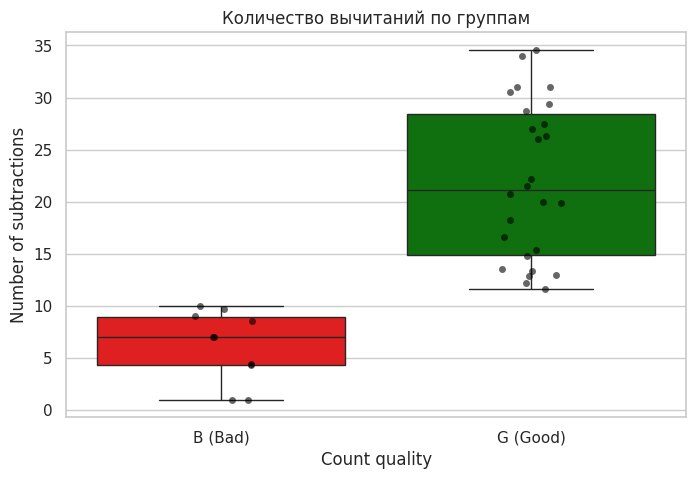

In [ ]:
sns.boxplot(data=info, x="Count quality", y="Number of subtractions", palette=["red","green"])
sns.stripplot(data=info, x="Count quality", y="Number of subtractions", color="black", alpha=0.6)
plt.xticks([0,1], ["B (Bad)", "G (Good)"])
plt.title("Количество вычитаний по группам")
plt.ylabel("Number of subtractions")
plt.show()

In [ ]:
Группа G выполняла в среднем 21 вычитание, а группа B - 7.
То есть действительно есть различие в качестве выполнения задания.

# Подготовка и чтение EDF-файлов

Для каждого испытуемого возьмем:

*_1.edf — состояние покоя,

*_2.edf — выполнение задачи.

In [ ]:
# Список субъектов
def subject_ids():
    edfs = sorted([f for f in os.listdir(BASE) if f.endswith(".edf")])
    subs = sorted({re.match(r'(Subject\d+)_', f).group(1) for f in edfs})
    return subs

SUBS = subject_ids()

In [ ]:
print(f"Найдено субъектов: {len(SUBS)}")

Найдено субъектов: 36


Считаем EDF-файлы для каждого субъекта.

Фильтруем каналы EEG от 1 до 45 Гц и унифицируем до 128 Гц.

Каналы переименуем для удобства анализа (удален префикс EEG ).

In [ ]:
def load_raw(path):
    """
    Читаем EDF, оставляем только EEG, фильтруем 1-45 Гц, ресемплим до 128 Гц.
    """
    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    # Канал-нейминг: "EEG Fz" -> "Fz"
    ch_renames = {ch: ch.replace("EEG ", "") for ch in raw.ch_names}
    mne.rename_channels(raw.info, ch_renames)
    # Оставляем EEG
    picks = mne.pick_types(raw.info, eeg=True, eog=False, ecg=False)
    raw.pick(picks)
    # Полосовой фильтр и ресемпл
    raw.filter(1., 45., fir_design='firwin', verbose=False)
    raw.resample(128, npad="auto")
    return raw

Мы будем анализировать три диапазона частот ЭЭГ: Theta (4-7 Гц), Alpha (8-13 Гц), Beta (13-30 Гц)

In [ ]:
# Частотные диапазоны и зоны
EEG_BANDS = {
    "theta": (4, 7),
    "alpha": (8, 13),
    "beta":  (13, 30),
}
FRONTAL = ["Fp1","Fp2","F3","F4","Fz"]
PARIETAL = ["P3","P4","Pz"]

In [ ]:
def rel_bandpowers(raw):
    """Считаем относительные мощности в тета, альфа и бета диапазонах"""
    data = raw.get_data()  # shape: (n_channels, n_times)
    sf = raw.info['sfreq']
    f, psd = welch(data, fs=sf, nperseg=int(sf*2), axis=1)  # psd: (n_ch, n_freq)
    mask_total = (f >= 1) & (f <= 45)
    total = psd[:, mask_total].sum(axis=1) + 1e-12  # защита от деления на 0

    feats = {}
    for band, (f1, f2) in EEG_BANDS.items():
        mask = (f >= f1) & (f <= f2)
        bandpow = psd[:, mask].sum(axis=1)
        feats[f"{band}_per_channel"] = bandpow / total
    feats["freqs"] = f
    feats["psd"] = psd
    feats["ch_names"] = raw.ch_names
    return feats

def pick_indices(ch_names, wanted):
    """Возвращает индексы каналов из wanted, которые присутствуют в записи."""
    wanted = set(wanted)
    return [i for i, ch in enumerate(ch_names) if ch in wanted]

def zone_mean(arr, idxs):
    """Среднее по выбранным каналам зоны (если нет - вернем NaN)."""
    return float(np.nanmean(arr[idxs])) if idxs else np.nan

Вычисляются относительные мощности для трех диапазонов: theta (4-7 Гц), alpha (8-13 Гц), beta (13-30 Гц).

Мощности нормируются на суммарную мощность 1-45 Гц.

Рассчитываются средние значения для фронтальных и париетальных зон.

# Сбор признаков по всем субъектам

Теперь для каждого участника посчитаем относительные изменения (задача / фон)
в трех диапазонах для двух зон:

лобная (front) — область концентрации и контроля;

теменная (par) — зона обработки сенсорной информации.

In [ ]:
rows = []
per_subject_cache = {}

for sub in SUBS:
    rest_path = os.path.join(BASE, f"{sub}_1.edf")
    task_path = os.path.join(BASE, f"{sub}_2.edf")
    if not (os.path.exists(rest_path) and os.path.exists(task_path)):
        continue

    raw_rest = load_raw(rest_path)
    raw_task = load_raw(task_path)

    fr = rel_bandpowers(raw_rest)
    ft = rel_bandpowers(raw_task)

    chn = fr["ch_names"]
    idx_front = pick_indices(chn, FRONTAL)
    idx_par = pick_indices(chn, PARIETAL)

    feat_row = {"Subject": sub}
    for band in EEG_BANDS:
        r_arr = fr[f"{band}_per_channel"]
        t_arr = ft[f"{band}_per_channel"]

        feat_row[f"{band}_front_ratio"] = zone_mean(t_arr, idx_front) / (zone_mean(r_arr, idx_front) + 1e-12)
        feat_row[f"{band}_par_ratio"]   = zone_mean(t_arr, idx_par)   / (zone_mean(r_arr, idx_par) + 1e-12)

    # Метка качества
    feat_row["Label"] = label_map.get(sub, np.nan)

    if len(per_subject_cache) < 2:
        per_subject_cache[sub] = {"rest": fr, "task": ft}

    rows.append(feat_row)

df = pd.DataFrame(rows)

In [ ]:
# Добавим поля из метаданных (кол-во вычитаний и пр.)
df = df.merge(info[["Subject","Number of subtractions","Count quality"]], on="Subject", how="left")
df.rename(columns={"Number of subtractions": "n_subtractions", "Count quality": "count_quality"}, inplace=True)

print("Размер итоговой таблицы признаков:", df.shape)
display(df.head())

Размер итоговой таблицы признаков: (36, 10)


,Subject,theta_front_ratio,theta_par_ratio,alpha_front_ratio,alpha_par_ratio,beta_front_ratio,beta_par_ratio,Label,n_subtractions,count_quality
0,Subject00,0.899649,1.232969,0.771619,0.728241,0.862952,1.157641,0,9.70,0
1,Subject01,1.614186,0.863493,0.667324,0.492699,0.587529,0.716572,1,29.35,1
2,Subject02,0.941531,0.806875,0.910167,0.974023,1.043949,1.548492,1,12.88,1
3,Subject03,1.060923,1.311765,0.519793,0.618603,0.820526,1.096420,1,31.00,1
4,Subject04,1.199415,1.456386,0.985746,0.784988,1.064618,1.523702,0,8.60,0


# Индекс усилий и нормализация

In [ ]:
# Индекс усилий = theta_front_ratio + beta_front_ratio - alpha_par_ratio
df["EffortScore"] = df["theta_front_ratio"] + df["beta_front_ratio"] - df["alpha_par_ratio"]

# Робастная Z-нормализация
from scipy.stats import median_abs_deviation
df["EffortScore_z"] = (
    df["EffortScore"] - df["EffortScore"].median()
) / (median_abs_deviation(df["EffortScore"], scale='normal') + 1e-12)

Фронтальная тета и бета ассоциируются с концентрацией и когнитивной активностью, а париетальная альфа с расслаблением. Таким образом, индекс отражает баланс усилия и расслабления.

In [ ]:
# Разделение по медиане на две группы (Predicted) и сравнение с меткой качества счета (Label: 1=G, 0=B).
median_thr = df["EffortScore_z"].median()
df["Predicted"] = (df["EffortScore_z"] > median_thr).astype(int)  # 1 = "скорее G"

# Статистический анализ различий

In [ ]:
group_g = df[df["Label"]==1]["EffortScore_z"]
group_b = df[df["Label"]==0]["EffortScore_z"]

u, p = mannwhitneyu(group_g, group_b)
print(f"Mann–Whitney p = {p:.3f}")
print(f"Средние значения: G={group_g.mean():.3f}, B={group_b.mean():.3f}")

Mann–Whitney p = 0.448
Средние значения: G=0.236, B=-0.200


p ≈ 0.45 — статистически значимых отличий между G и B по EffortScore_z не найдено, но средние по группам соответствуют гипотезе (G > B), эффект — малый/умеренный.

Несмотря на отсутствие статистической значимости, видна тенденция, что более добросовестные субъекты проявляют чуть более высокий индекс усилий.

# Визуализация

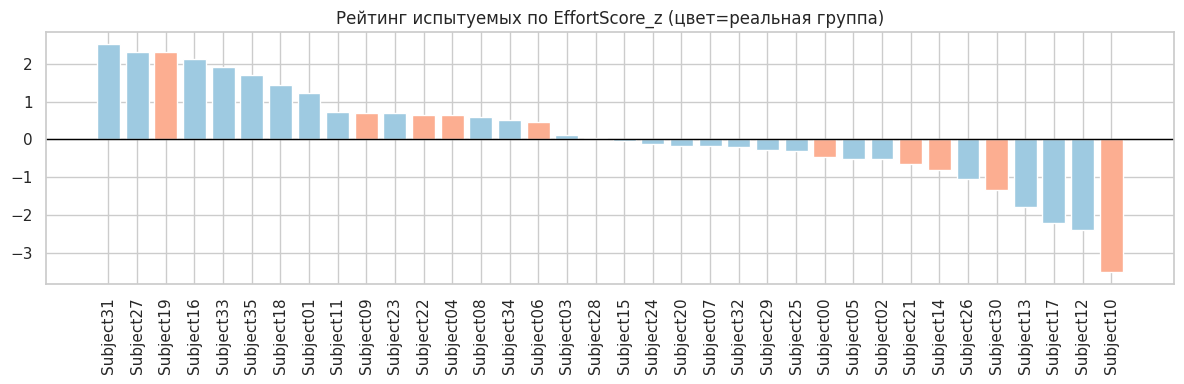

In [ ]:
df_sorted = df.sort_values("EffortScore_z", ascending=False).reset_index(drop=True)
plt.figure(figsize=(12,4))
colors = df_sorted["Label"].map({0:"#fcae91", 1:"#9ecae1"})
plt.bar(df_sorted["Subject"], df_sorted["EffortScore_z"], color=colors)
plt.xticks(rotation=90)
plt.axhline(0, color="black", lw=1)
plt.title("Рейтинг испытуемых по EffortScore_z (цвет=реальная группа)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-69043084.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Label", y="EffortScore_z", data=df, palette=["red","green"])


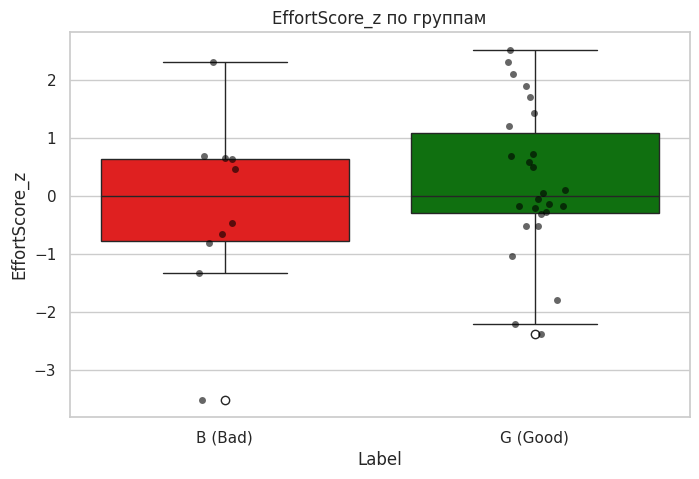

In [ ]:
plt.figure()
sns.boxplot(x="Label", y="EffortScore_z", data=df, palette=["red","green"])
sns.stripplot(x="Label", y="EffortScore_z", data=df, color="black", alpha=0.6)
plt.xticks([0,1], ["B (Bad)", "G (Good)"])
plt.title("EffortScore_z по группам")
plt.show()

In [ ]:
# Выявление "халявщиков" и "старателей" по квартилям
g_low  = df[(df["Label"]==1) & (df["EffortScore_z"] < group_g.quantile(0.25))]
b_high = df[(df["Label"]==0) & (df["EffortScore_z"] > group_b.quantile(0.75))]
print("Потенциальные 'халявщики' (G, низкий EffortScore):", g_low["Subject"].tolist())
print("Потенциальные 'старатели' (B, высокий EffortScore):", b_high["Subject"].tolist())

Потенциальные 'халявщики' (G, низкий EffortScore): ['Subject02', 'Subject05', 'Subject12', 'Subject13', 'Subject17', 'Subject25', 'Subject26']
Потенциальные 'старатели' (B, высокий EffortScore): ['Subject09', 'Subject19', 'Subject22']


В группе G есть несколько участников с низким уровнем активности -
возможно, они решали механически.

В группе B - наоборот, встречаются люди с высокой активностью,
что говорит о старании, но меньшей эффективности.

# Общие выводы

Спектральный анализ ЭЭГ показал тенденцию: успешные участники демонстрируют усиление θ/β и подавление α, что соответствует модели когнитивного напряжения.

Средний EffortScore_z выше у «хороших» участников (группа G).

Есть участники, которые работали старательно, но без результата,
и наоборот выполнили задачу успешно, не напрягаясь. Различия не достигают статистической значимости, что может указывать на высокую межиндивидуальную вариабельность и ЭЭГ измеряет процесс мышления, а не только результат.

Индекс может использоваться как простой индикатор вовлеченности,
но для большей точности стоит добавить больше признаков.